# <font color="red">**2.2 Procesamiento de distintos formatos de datos </font> (`.csv`, `.xlsx`, `.txt`)** 

En el análisis científico y profesional, los datos pueden provenir de múltiples fuentes y almacenarse en distintos formatos como `.csv`, `.xlsx`, `.txt`, NetCDF (`.nc`), entre otros. Saber procesarlos es fundamental para garantizar un análisis correcto y eficiente. En Python, la paquetería por excelencia para cargar distintos formatos de datos es **Pandas**.

In [ ]:
#Importando paqueterías útiles para procesar datos
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

------------

## <font color="darkblue"> **Formato `.csv`**

Los datos en formato **CSV** (*Comma-Separated Values*) es una de las formas más comunes de almacenar y compartir datos. En un archivo _CSV_, los datos **se organizan en forma de tabla**, donde cada fila representa una observación o registro y cada columna representa una variable o característica. Los valores de este tipo de datos están separados por comas (o por otro delimitador, como un punto y coma o una tabulación). 

El estar formateados por comas hace que los archivos _CSV_ sean **fáciles de leer y escribir tanto para humanos como para computadoras**. Una de las principales ventajas del formato _CSV_ es su **simplicidad y su compatibilidad con una amplia gama de herramientas de análisis de datos**, como hojas de cálculo, bases de datos y lenguajes de programación como Python.

La lectura y escritura de archivos CSV con Pandas es fundamental para importar datos desde diferentes fuentes, como hojas de cálculo, bases de datos y sistemas de almacenamiento en la nube, así como para exportar datos procesados a diferentes formatos. En esta clase, exploraremos cómo usar Pandas para leer datos de archivos CSV en un DataFrame de Pandas y cómo escribir un DataFrame de Pandas de vuelta a un archivo CSV.


#### **<font color="YellowGreen"> Calidad del Aire </font>** 

Trabajaremos con una base de datos en formato *csv* proveniente de la Red de Monitoreo de calidad del aire de la Secretaría del Medio Ambiente de la CDMX (<http://www.aire.cdmx.gob.mx/aire/default.php>). Específicamente, procesaremos datos de ozono ($O_3$). Para conocer más sobre el ozono, visita: 

- <https://planeteando.org/2020/03/31/el-ozono-en-la-region-mas-transparente-durante-la-cuarentena/>

- <https://www.comoves.unam.mx/numeros/aquiestamos/210>

Vamos a cargar nuestra base de datos.

**¿Cómo leemos archivos CSV en Python?**

Utilizamos la función `pd.read_csv()` para leer un archivo CSV y cargar los datos en un DataFrame de Pandas (<https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html>). 
La sintaxis de `pd.read_csv()` es sencilla, siempre y cuando nuestros datos de csv estén bien formateados de origen. 

*Spoiler, la Red de Monitoreo no los tiene tan bonitos como aquí* 

Para usar `pd.read_csv()` solo le damos como argumento un `str` que sea la dirección **correcta** de nuestro archivo. 


In [ ]:
#Cargando archivo csv
datos_o3=pd.read_csv("datos_limpios_O3.csv")
datos_o3

<font color="brown">**Es importante que cuando trabajemos con datos, conozcamos sus características (columnas, filas, información de los datos)antes que efectuar análisis.**

Estos datos tienen 3 columnas y 277604 filas. Dentro de las columnas tenemos:

- Date: La fecha en formato de año, mes, día, hora, minuto y segundo. 
- value: valor de concentración medido
- id_station: nombre o identificador de la estación.


**Información de los datos**

- *Periodo*: los datos van de enero 2022 a enero 2023.
- *Frecuencia*: horaria, mediciones de concentración promedio cada hora. 
- *Unidades*: ppb.
  
------
### **<font color="darkblue"> Pequeñas transformaciones de datos </font>**

A menos que ya hayan procesado mucho sus datos, seguramente los datos "crudos" no serán directamente útiles para su análisis y querrán cambiar algunas cosas que no les gusten. 

  - **Renombrar columnas** 

  - **Convertir objetos de fecha y hora en formato `datetime`**

  - **Transformar fechas a índices**

#### <font color="orange"> **Ejemplo 1: Renombrando columnas**

Para cambiarle el nombre a una columna, se utiliza el método `.rename`, el cuál requiere un diccionario que le diga qué cambios se hacen, primero el nombre anterior y luego el nombre nuevo, y en qué eje. Las columnas en Pandas son el eje 1, mientras que las filas son el eje 0.



In [ ]:
# Renombrando los nombres de columnas
# Cambiando 'id_station' por 'Estacion' y 'value' por 'Concentracion'

datos_o3=datos_o3.rename({'id_station':'Estacion',"value":"Concentracion"},axis=1) #En el diccionario puedo definir 
datos_o3                                                                       #tantas variables quiera cambiarle el nombre


In [ ]:
#En lugar de axis=1, puedes ocupar esta otra manera
datos_o3=datos_o3.rename(columns={'id_station':'Estacion',"value":"Concentracion"}) 
datos_o3

In [ ]:
#¿Y si quiero cambiar una fila? Como tal solo cambia el valor del índice de cada fila
df_example = pd.DataFrame({
    "Temp": [25, 26, 27],
    "Hum": [60, 58, 65]
})
df_example

In [ ]:
df_example=df_example.rename({0: "Día1", 1: "Día2"},axis=0)
df_example

#### <font color="orange"> **Ejemplo 2: Datetime**

El método `pd.to_datetime` en Pandas se utiliza para convertir objetos de fecha y hora en el formato `datetime` de Python. Este método es extremadamente útil cuando se trabaja con datos de series temporales, ya que permite manipular y analizar fácilmente fechas y horas en un DataFrame de Pandas.

Cuando se aplica `pd.to_datetime` a una serie o columna de un DataFrame de Pandas que contiene datos de fecha y hora en diferentes formatos (como cadenas de texto, números enteros o objetos de fecha y hora), **Pandas intentará convertir estos datos en objetos datetime de Python de manera inteligente y eficiente. Esto significa que el método pd.to_datetime puede manejar una variedad de formatos de entrada**, incluidas fechas y horas en formato ISO, formatos de fecha comunes, como 'YYYY-MM-DD', y formatos personalizados.


In [ ]:
#Primero vamos a checar qué tipo de datos es la columna Date
datos_o3["Date"].dtype

In [ ]:
#Convirtiendo las fechas a formato datetime
datos_o3['Date']=pd.to_datetime(datos_o3.Date)
datos_o3

In [ ]:
#Ahora vamos a checar qué tipo de datos es Date
datos_o3["Date"]

#### <font color="orange"> **Ejemplo 3: Fechas como índices**
Ahora cambiaremos el índice y lo sustuiremos por la columna de fecha. ¿Por qué? Es útil que el índice en un DataFrame de Pandas esté en formato `pd.to_datetime` por varias razones:

- **Facilidad de manipulación temporal**: Al tener el índice en formato datetime, Pandas proporciona una amplia gama de métodos y funciones para realizar operaciones de indexación y selección basadas en fechas y horas. Esto facilita la realización de análisis temporales, como filtrar datos por rangos de fechas, realizar agregaciones temporales y calcular diferencias temporales.

- **Interpolación y rellenado de datos faltantes**: Pandas ofrece funcionalidades de interpolación y rellenado de datos faltantes que pueden ser particularmente útiles en datos de series temporales. Al tener el índice en formato datetime, Pandas puede interpolarse y rellenarse fácilmente valores faltantes basados en fechas y horas.

- **Visualización y gráficos temporales**: Tener el índice en formato datetime facilita la creación de visualizaciones y gráficos temporales utilizando herramientas integradas de Pandas y bibliotecas de visualización como Matplotlib y Seaborn. Esto permite explorar y comunicar patrones temporales en los datos de manera efectiva.


In [ ]:
# sustituimos el indice
datos_o3.index=datos_o3.Date

In [ ]:
#Veamos qué nos hizo
# Imprimimos las primeras columnas

print(datos_o3.head())

In [ ]:
# ¿Cómo nos deshacemos de la columna Date pero no del índice?

datos_o3=datos_o3.drop('Date',axis=1)
datos_o3

<font color="brown">**Ahora que el índice tiene formato de fecha, accedemos a toda una gama de atributos, funciones y posibilidades de manipular nuestros datos con fechas. Entre los atributos más utilizados se encuentra el uso de `month`, `day` y `year`**.

La lista completa de atributos de un `DataFrame.DatetimeIndex` la pueden encontrar aquí:

<https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.html>

In [ ]:
#Acceder a los meses 
datos_o3.index.month

In [ ]:
#Acceder a los años
datos_o3.index.day

**Podemos usar estos atributos para hacer un slice sobre el dataframe original. Es decir, vamos a recortar los datos a sólo los datos del 2023.**

In [ ]:
#¿Qué usabamos para hacer recortes a un dataframe? 

**Y ahora solamente a los datos de febrero. Noten bien que los meses se cuentan desde el 1 hasta el 12. El 12 es diciembre, naturalmente.**

------

### <font color="darkblue"> **Otros métodos de Pandas útiles para operar rápidamente nuestra base de datos.** 

- `unique()`: Este método se utiliza para obtener los valores únicos en una serie. Es especialmente útil cuando se quiere identificar los distintos valores presentes en una columna de un DataFrame.

- `value_counts()`: Este método cuenta la frecuencia de cada valor único en una serie. Es útil para determinar la distribución de los valores en una columna.


#### <font color="orange"> **Ejemplo 1: Cuáles son las estaciones únicas en nuestra base de datos**

In [ ]:
datos_o3["Estacion"].unique()

#### <font color="orange"> **Ejemplo 2: Cuántas veces se repite la concentración 0**


In [ ]:
# slice para agarrar concentracion de 0.
print(datos_o3.loc[datos_o3['Concentracion']==0])

print("**********************")

# cuantas veces contamos concentracion de 0 ppb en cada estacion
cuentas=datos_o3[datos_o3['Concentracion']==0].value_counts()
print(cuentas)

In [ ]:
#Total de veces por estacion que registra concentraciones=0

-----

### <font color="darkblue">**Más slicing**

Como ya hemos aludido en celdas pasadas al concepto de slicing, veremos un poco más de cómo recortar nuesto dataframe. La sintaxis básica de slicing en Pandas es con `df.loc[condition]` que se utiliza para seleccionar un subconjunto de filas de un DataFrame que cumplan con cierta condición. Sin embargo, existen otros métodos de slicing.

#### <font color="orange"> **Ejemplo 1: Usaremos la estación del CCA, lo que ahora es el _Instituto de Ciencias de la Atmósfera y Cambio Climático_**

In [ ]:
#Aquí otro ejemplo para seleccionar una estación específica de todas las estaciones de monitoreo 
#y sólo quedarnos con los datos de esa estación. 

CCA=datos_o3[datos_o3["Estacion"]=="CCA"]
CCA

**También podemos utilizar una lista de estaciones y quedarnos sólo con los datos de esas estaciones. Para esto, se usa el método `isin(lista)` que nos permite evaluar si un objeto, está en una lista.** 

#### <font color="orange"> **Ejemplo 2: Recorte con varias estaciones**

In [ ]:
# Lista de estaciones con las que me voy a quedar
lista_estaciones=['CCA','PED','BJU','COY']

# Slice de estaciones con las que sí me quiero quedar
df_estaciones=datos_o3[datos_o3.Estacion.isin(lista_estaciones)]

# Nuevo dataframe solo con estaciones seleccionadas
df_estaciones

-------------

**Una de las grandes ventajas de Pandas es que fácilmente podemos graficar e interpretar nuestros datos. 
Por ejemplo, podemos graficar el tiempo contra la concentración para nuestros datos del CCA.**

Para esto, se puede seleccionar la columna y simplemente dar la instrucción de `plot()`

In [ ]:
#Retomamos nuestro dataframe CCA

CCA.Concentracion.plot()  #Por default, toma el índice como el eje x
plt.show()

<div class="alert alert-block alert-info">
<b>Nota:</b> El código anterior supo cómo graficar exactamente la serie de tiempo porque las columnas de Pandas son objetos llamados Series y las Series siempre tienen asociado el índice del DataFrame. Específicamente, este DataFrame y su columna de Concentración tienen un índice de tiempo tipo Datetime, que definimos algunas celdas arriba. 
</div>

In [ ]:
#Vamos a verificar lo anterior

### **<font color="darkblue"> Pequeñas/grandes transformaciones de datos </font>**

Ahora que sabemos lo básico de Pandas podemos pasar a transformaciones un poco más complicadas. 

La clase pasada vimos lo que hace el método de `groupby` y `mean`.

Por ejemplo, preguntas que nos podrían surgir:

- **¿Cuál es el promedio de ozono por estación?**

- **¿Qué estaciones creen que tengan la peor calidad del aire (medida por ozono)?**

Para contestar estas preguntas, primero agrupamos todos los datos por estación y luego sacamos el promedio, en este caso de la concentración. 



In [ ]:
# agrupamos, genera un objeto del tipo groupby, no obtenemos algo interesante
print(datos_o3.groupby(datos_o3.Estacion))

In [ ]:
# pero si le sacamos el operador mean
print(datos_o3.groupby(datos_o3.Estacion).mean())

In [ ]:
datos_mean=datos_o3.groupby(datos_o3.Estacion).mean()['Concentracion']

In [ ]:
#¿Qué estaciones creen que tengan la peor calidad del aire (medida por ozono)?


<font color="brown"> **Ahora que tenemos una nueva base de datos, podemos guardar nuestros datos en otro archivo. Para esto se utiliza el método de `to_csv` que guarda un dataframe en un archivo. El nombre del archivo es el argumento de la función, así que mucho ojo con donde queremos guardar los archivos.**

In [ ]:
datos_mean.to_csv("datos_promedio.csv")

------

### <font color="darkblue"> **Más operaciones con el tiempo**

Una operación fundamental con pandas una vez que el índice es del tipo DatetimeIndex es cambiar la resolución temporal de los datos. Por ejemplo, esta base de datos tiene una resolución temporal de 1 hora pero quizás sea útil pasarlos a datos diarios.

Para esto, se utiliza el método `resample()` y el operador `mean()`. Resample cambia la resolución o el "sampleado" de los datos. Como argumento, toma la nueva resolución donde la letra `D` significa días y el valor de 1 quiere decir que la nueva resolución es de 1 día (<https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html>).

In [ ]:
#Retomando datos_o3


### **<font color="Orange">Ejercicio 1: </font>**

A partir de `datos_o3`, obten lo siguiente:

1. Obtener el promedio por mes de las concentraciones de ozono en todas las estaciones. 
    
2. Graficar los resultados y mostrar el ciclo estacional del ozono.

## <font color="darkblue"> **Formato `.xlsx`**

El formato **XLSX** es el tipo de archivo estándar utilizado por Excel para almacenar hojas de cálculo. **Permite organizar datos en filas y columnas** dentro de una o varias hojas en un mismo archivo, además de incluir formato visual como colores, estilos, tablas, gráficos y fórmulas matemáticas. 

A diferencia de formatos más simples como *CSV*, el *XLSX* no solo guarda datos, sino también su estructura y presentación, lo que lo hace especialmente útil para análisis exploratorio, elaboración de reportes y organización de información en ámbitos académicos, científicos y profesionales.

#### **<font color="YellowGreen"> Emisiones de Gases de Efecto Invernadero (GH) de la Energía  </font>** 

Para esta parte, usaremos un extracto libre de datos de Emisiones de Gases de Efecto Invernadero de Energía (anteriormente denominado Emisiones de $CO_2$ de Combustión de Combustión de Combustión). Este archivo contiene una amplia selección de datos de emisiones de gases de efecto invernadero del sector energético para más de 190 países y regiones (<https://www.iea.org/data-and-statistics/data-product/greenhouse-gas-emissions-from-energy-highlights>). 

Vamos a cargar nuestra base de datos.

**¿Cómo leemos archivos XLSX en Python?**

Utilizamos la función `pd.read_excel()` para leer un archivo XLSX y cargar los datos en un DataFrame de Pandas. 
La sintaxis de `pd.read_excel()`, suele ser un poco confusa debido a la presentación y estructura de los datos. 

Para usar `pd.read_excel()` solo le damos como argumento un `str` que sea la dirección **correcta** de nuestro archivo (<https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html>). En caso de que nuestra hoja de cálculo alamacene más de una hoja, podemos seleccionar la que querramos usar mediante el argumento `sheet_name`.



In [ ]:
#Cargando el archivo Excel
excel_GH=pd.read_excel("GHGHighlights.xlsx")
excel_GH  #De entrada, ¿Cómo se ven los datos?

----

**A simple vista es muy difícil entender los datos, por lo que antes de analizarlos, e inclusive descargarlos, es importante conocer con qué estamos trabajando.**

En este caso particular, no podemos intuir características de los datos con solo ver el DataFrame. Por ello, debemos de buscar otra manera de hacerlo.

Muchas fuentes de datos proporcionan la **documentación** de cada conjunto de datos. Una documentación, en base de datos, es el conjunto de información escrita que describe cómo está estructurada, organizada y cómo debe usarse una base de datos. Es, básicamente, el “manual” que explica qué contienen los datos y cómo interpretarlos correctamente.

Vamos a ver la documentación de nuestros datos: <https://iea.blob.core.windows.net/assets/21739032-3ad7-4ef8-a43a-ec6a5498ecd3/Databasedocumentation2025edition.pdf> 

-----

<font color="brown"> **Ahora sí continuemos.**

Una vez vista la estructura de nuestros datos, podemos decidir con cuál de todas las hojas queremos trabajar. En este caso eligiremos las emisiones agregadas por sector y producto energético ("GHG Energy"). Para poder elegirla ocupamos el argumento `sheet_name`.

In [ ]:
#Eligiendo la hoja de "GHG Energy"
#Podemos hacerlo de dos maneras

#Manera 1: Si conocemos el nombre de la hoja
df_energy = pd.read_excel("GHGHighlights.xlsx", sheet_name="GHG Energy")

#Manera 2: Si conocemos la posición de la hoja (0,1,2,3,.....)
df_energy1 = pd.read_excel("GHGHighlights.xlsx", sheet_name=1)

In [ ]:
#¿Si no recuerdo los nombres o la posición de la hoja

#Podemos ver todos los nombres de las hojas dentro de nuestro Excel
df_energy2 = pd.read_excel("GHGHighlights.xlsx",sheet_name=None)  #sheet_name=None: Lee todas las hojas, df_energy2 será un diccionario
df_energy2 
#df_energy2.keys() ##Las claves del diccionario son los nombres de las hojas.

**Ahora ya tenemos la hoja que ocuparemos. Sin embargo, el formato de los datos todavía no es del todo útil, ya que cuenta con encabezado. ¿Cómo lo quitamos?** Usando `skiprows`

In [ ]:
#Usando skiprows
df_energy=pd.read_excel("GHGHighlights.xlsx", sheet_name="GHG Energy",skiprows=3) #¿Cuántas filas quiero saltarme?

In [ ]:
df_energy

**Ahora, ¿Qué creen que podríamos mejorar de nuestros datos?**

### <font color="darkblue"> **Valores faltantes**
Si pueden observar, al final de nuestro DataFrame aparecen valores 'NaN' que significa _not a number_. O sea que no hay datos en esas filas. 

Una manera de deshacernos de esos datos con pandas es con el método `dropna()`. `df.dropna()` es un método en Pandas que se utiliza para eliminar filas o columnas que contienen valores NaN (valores faltantes) de un DataFrame. El argumento `axis` especifica si se eliminarán filas o columnas que contienen valores NaN. Por defecto, `axis=0`, lo que significa que se eliminarán filas que contienen NaN. Pueden usar `axis=1` para eliminar columnas que contienen NaN.

#### <font color="orange"> **Ejemplo**

In [ ]:
#Eliminando los NaN
df_energy_snan=df_energy.dropna() #Por default axis=0
df_energy_snan

<font color="brown">**Una vez tengamos los datos en un buen formato, podemos analizarlos como cualquier DataFrame.**

OJO: Hasta el momento solo hemos modificado el formato de los datos dentro del código, pero si queremos guardar los cambios que hicimos para reutilizarlo en otro momento ¿Debo de hacer todo el proceso nuevamente?

Al igual que con los archivos CSV, nosotros podemos guardar los datos. Para ello usamos `df.to_excel()`.

In [ ]:
df_energy_snan.to_excel("datos_energy_clean.xlsx", index=False) #index=False evita que el índice se guarde como columna

-----

#### <font color="orange">**Ejercicio 2:**

1. Cambia el nombre de la primera columna de `df_energy_snan` a uno más sencillo de utilizar.
2. Muestra qué valores únicos tiene la primer columna.
3. Selecciona un país y recorta los datos para dicho país.
4. Encuentra en qué años emitió mayor y menor cantidad de GH.
5. Calcula el promedio de emisiones para ese país.

-------
## <font color="darkblue"> **Formato `.txt`**

El formato **TXT** es un tipo de archivo de texto plano que **almacena información únicamente como caracteres** (letras, números y símbolos), sin incluir formato visual como colores, tipos de letra, imágenes o fórmulas. Es uno de los formatos más simples y universales.

Cada línea en un archivo de texto suele representar un registro y los campos pueden **separarse por tabulaciones, espacios, comas o punto y coma**.

**Puntos clave:**

- Delimitador: aclara si usas tab (`\t`), espacios, coma o punto y coma.
- Encabezados y comentarios: a veces hay una fila con nombres de columnas o líneas que empiezan con `#` con metadatos.
- Codificación: preferir UTF-8 para acentos; indícala si no es la predeterminada.
 - Valores faltantes: define cómo se representan (NA, -9999, vacío).

**¿Cómo leemos archivos TXT en Python?**

`pandas.read_csv()` funciona para TXT si especificas el separador (`sep="\t"` para TSV, Tab-Separated Values, `delim_whitespace=True` para espacios) y comment=`"#"` para ignorar comentarios. Para columnas de ancho fijo,`read_fwf`.

#### **<font color="YellowGreen"> ONI (Oceanic Niño Index)  </font>** 


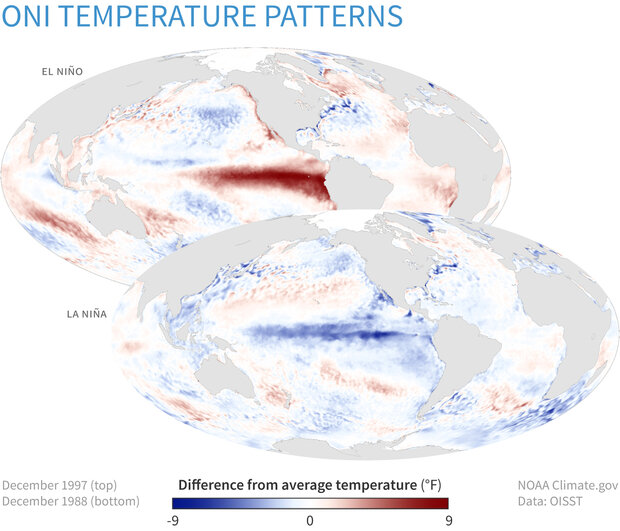


El **ONI** es un índice que resume el estado de **ENSO** (El Niño–La Niña) a partir de las **anomalías de temperatura superficial del mar** en la región Niño 3.4 (5°N–5°S, 170°W–120°W). Se calcula como un **promedio móvil de 3 meses** (DJF, JFM, FMA, …) usando una climatología de ~30 años y datos de TSM reconstruidos (ERSST). Se actualiza mensualmente.

**¿Para qué sirve?**
Es la referencia operativa más común para clasificar episodios:

- **El Niño**: ONI ≥ +0.5 °C durante 5 temporadas trimestres superpuestas.
- **La Niña**: ONI ≤ −0.5 °C durante 5 temporadas.
- **Neutral**: valores entre esos umbrales.

**Formato típico (TXT/ASCII)**

Tabla por **año** con 12 columnas de temporadas solapadas (DJF, JFM, …, NDJ) y valores en °C con signo. Es texto plano, fácil de leer con `pandas.read_csv(..., delim_whitespace=True)` y útil para ejercicios de:

- filtrado por año/temporada,
- conteo de meses/temporadas El Niño vs. La Niña,
- gráficos de líneas o barras por temporada.

**Notas prácticas**

- Las temporadas están solapadas (no tratarlas como meses independientes).
- La climatología se actualiza cada cierto tiempo; si comparas con otras fuentes, verifica el periodo base.


In [ ]:
#Vamos a cargar los datos del ONI, formato txt
oni=pd.read_csv('oni.ascii.txt')
oni #¿Cuántas columnas tiene?

In [ ]:
# Para que nos lo separe por columnas, necesitamos decir cómo se delimitan las columnas.
oni=pd.read_csv('oni.ascii.txt',delim_whitespace=True)

In [ ]:
#Vamos a visualizar nuestros datos de forma gráfica
import matplotlib.pyplot as plt
oni.ANOM.plot(c="k")
plt.ylabel('Indice')
plt.show()

**Haremos otro análisis: Conocer las temporadas donde el índice ONI supera los 0.5**

In [ ]:
# La tabla ONI típica: columnas por temporada de 3 meses (DJF, JFM, ..., NDJ)
seasons = ["DJF","JFM","FMA","MAM","AMJ","MJJ","JJA","JAS","ASO","SON","OND","NDJ"]
month_of = {"DJF":1, "JFM":2, "FMA":3, "MAM":4, "AMJ":5, "MJJ":6,
            "JJA":7, "JAS":8, "ASO":9, "SON":10, "OND":11, "NDJ":12}

In [ ]:
x_dates = []
y_vals  = []
x_scatter = []
y_scatter = []

for r in range(len(oni)):
    year = int(oni.YR.iloc[r])
    temporada=oni.SEAS.iloc[r]
    #print(temporada)
    month=month_of[temporada]
    x = pd.Timestamp(year=year, month=month, day=15)
    #print(x)
    x_dates.append(x)
    if oni.ANOM.iloc[r] >= 0.5:
            x_scatter.append(x)
            y_scatter.append(float(oni.ANOM.iloc[r]))
oni['fecha']=x_dates

In [ ]:
plt.figure(figsize=(10,3.55))
plt.plot(oni.fecha,oni.ANOM)
plt.scatter(x_scatter,y_scatter,c='tab:red')
plt.axhline(0, linewidth=1)
plt.xlabel("Fecha (temporadas ONI)")
plt.ylabel("ONI (°C)")
plt.title("Índice ONI y temporadas ≥ 0.5")
plt.tight_layout()

**Para guardar un archivo TXT podemos ocupar `df.to_csv("archivo.txt", index=False)`. Por default lo guarda separados por comas, pero tú puedes especificar cómo quieres que estén separados usando `sep="separador"`.**

-----

#### <font color="orange">**Ejercicio 3:**

1. De los datos originales de ONI, realiza un recorte para obtener solo los datos donde la anomalía el valor de 0.5.
2. Agrupa los datos recortados por temporada y cuenta cuántos anomalías mayores a 0.5 hubieron.
3. Realiza una gráfica de tu elección para representar tus resultados del punto 2. Es decir, que representen cuántas veces se presentaron anomalías superiores a los 0.5 por temporada.